In [48]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [51]:
import load_data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from IPython.display import display, Markdown, Math
import numpy as np
from scipy.stats import norm
from scipy.stats import chi2_contingency
import src.analysis_utils as analysis_utils

In [12]:
df_transition = load_data.load("transition")
df_transition.head(30)

transition table loaded!


,client_id,variation,visit_seq,step_rank,next_rank,step_diff,date_time,transition_type
0,555,Test,1,1,2.0,1.0,2017-04-15 12:57:56+00:00,forward
1,555,Test,2,2,3.0,1.0,2017-04-15 12:58:03+00:00,forward
2,555,Test,3,3,4.0,1.0,2017-04-15 12:58:35+00:00,forward
3,555,Test,4,4,5.0,1.0,2017-04-15 13:00:14+00:00,forward
4,555,Test,5,5,NaN,NaN,2017-04-15 13:00:34+00:00,end
5,647,Test,1,1,2.0,1.0,2017-04-12 15:41:28+00:00,forward
6,647,Test,2,2,3.0,1.0,2017-04-12 15:41:35+00:00,forward
7,647,Test,3,3,4.0,1.0,2017-04-12 15:41:53+00:00,forward
8,647,Test,4,4,5.0,1.0,2017-04-12 15:45:02+00:00,forward
9,647,Test,5,5,NaN,NaN,2017-04-12 15:47:45+00:00,end


In [18]:
transition_summary = df_transition.groupby('variation')['transition_type'].value_counts(normalize=True).reset_index()

<Axes: xlabel='transition_type', ylabel='proportion'>

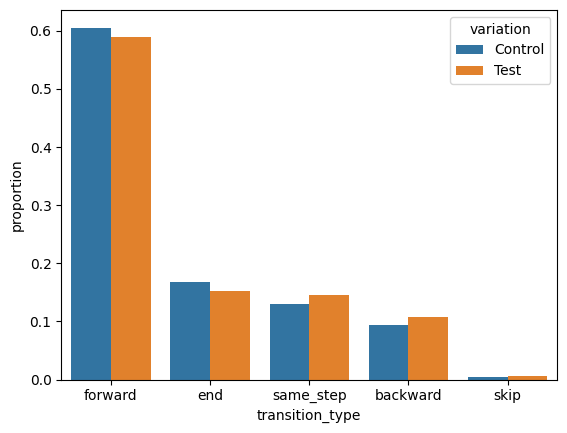

In [19]:
sns.barplot(
    data=transition_summary,
    x='transition_type',
    y='proportion',
    hue='variation'
)

In [20]:
transition_table = pd.crosstab(
    df_transition['variation'],
    df_transition['transition_type']
)
transition_table

transition_type,backward,end,forward,same_step,skip
variation,,,,,
Control,13205,23532,85092,18170,537
Test,19019,26968,104108,25634,970


In [23]:
chi2, p_value, dof, expected = chi2_contingency(
    transition_table
)

print("Chi-square:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)
print("\nExpected frequencies:")
print(expected)

Chi-square: 474.04647036374485
P-value: 2.7462257274600655e-101
Degrees of freedom: 4

Expected frequencies:
[[ 14275.32291204  22371.64247325  83816.13378095  19405.29558214
     667.60525163]
 [ 17948.67708796  28128.35752675 105383.86621905  24398.70441786
     839.39474837]]


In [26]:
observed = transition_table.to_numpy()
expected = np.asarray(expected)

residuals = (
    observed - expected
) / np.sqrt(expected)

residuals_df = pd.DataFrame(
    residuals,
    index=transition_table.index,
    columns=transition_table.columns
)

display(residuals_df.round(2))

transition_type,backward,end,forward,same_step,skip
variation,,,,,
Control,-8.96,7.76,4.41,-8.87,-5.05
Test,7.99,-6.92,-3.93,7.91,4.51


In [27]:
pd.crosstab(
    df_transition['step_rank'],
    df_transition['transition_type']
)

transition_type,backward,end,forward,same_step,skip
step_rank,,,,,
1,0,11159,59435,29379,1180
2,11138,3876,50110,2806,280
3,8041,1306,45859,1419,47
4,10520,2234,33796,1714,0
5,2525,31925,0,8486,0


In [52]:
df_client = load_data.load("client_profile")

""""
df_client['age_group'] = pd.cut(
    df_client['clnt_age'],
    bins=[0, 40, 60, 200],
    labels=['<40', '40-60', '60+'],
    right=False
)
"""

df_client = analysis_utils.add_segment(
    df_client,
    column="clnt_age",
    bins=[0,40,60,float("inf")],
    labels=["<40","40-60","60+"],
    segment_name="age_group"
)

df_transition_age = df_transition.merge(
    df_client[['client_id', 'age_group']],
    on='client_id',
    how='left'
)

step_transition_age = pd.crosstab(
    [
        df_transition_age['age_group'],
        df_transition_age['variation'],
        df_transition_age['step_rank']
    ],
    df_transition_age['transition_type'],
    normalize='index'
).round(3)

step_transition_age

client_profile table loaded!


transition_type                backward    end  forward  same_step   skip
age_group variation step_rank                                            
<40       Control   1             0.000  0.125    0.601      0.269  0.005
                    2             0.089  0.064    0.813      0.032  0.002
                    3             0.102  0.041    0.831      0.024  0.001
                    4             0.199  0.050    0.724      0.026  0.000
                    5             0.087  0.857    0.000      0.056  0.000
          Test      1             0.000  0.107    0.648      0.237  0.008
                    2             0.178  0.040    0.747      0.032  0.002
                    3             0.132  0.024    0.827      0.016  0.001
                    4             0.118  0.033    0.834      0.015  0.000
                    5             0.023  0.774    0.000      0.202  0.000
40-60     Control   1             0.000  0.124    0.570      0.299  0.008
                    2             0.110  0.072    0.771      0.043  0.005
                    3             0.111  0.026    0.820      0.042  0.002
                    4             0.219  0.048    0.696      0.037  0.000
                    5             0.105  0.793    0.000      0.101  0.000
          Test      1             0.000  0.100    0.591      0.293  0.016
                    2             0.198  0.041    0.720      0.038  0.003
                    3             0.182  0.019    0.776      0.023  0.000
                    4             0.201  0.038    0.727      0.034  0.000
                    5             0.031  0.713    0.000      0.256  0.000
60+       Control   1             0.000  0.120    0.539      0.330  0.011
                    2             0.173  0.095    0.677      0.048  0.008
                    3             0.106  0.015    0.849      0.029  0.000
                    4             0.274  0.072    0.605      0.050  0.000
                    5             0.126  0.707    0.000      0.167  0.000
          Test      1             0.000  0.092    0.563      0.325  0.020
                    2             0.214  0.048    0.674      0.057  0.006
                    3             0.201  0.012    0.770      0.016  0.000
                    4             0.329  0.046    0.567      0.057  0.000
                    5             0.032  0.618    0.000      0.350  0.000

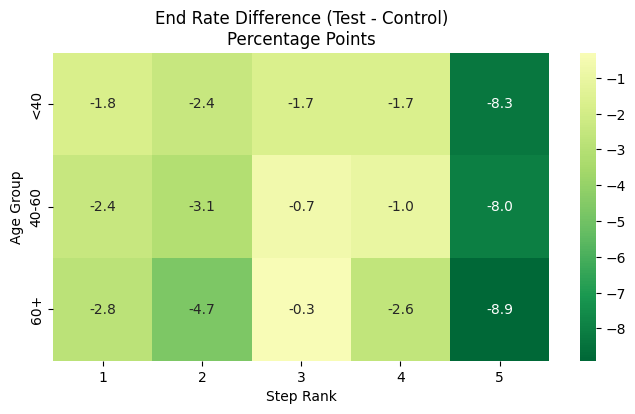

In [53]:
end_rate = (
    step_transition_age['end']
    .reset_index()
)
pivot = end_rate.pivot(
    index=['age_group', 'step_rank'],
    columns='variation',
    values='end'
)
pivot['diff'] = (
    pivot['Test']
    - pivot['Control']
) * 100
heatmap_data = pivot['diff'].unstack()

plt.figure(figsize=(8,4))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    center=0,
    cmap="RdYlGn_r"
)

plt.title(
    "End Rate Difference (Test - Control)\nPercentage Points"
)

plt.xlabel("Step Rank")
plt.ylabel("Age Group")

plt.show()